# 03 - Explicabilite SHAP

Objectif : repondre a la question du CDO : **Comment un analyste peut-il comprendre pourquoi une transaction est bloquee ?**

Ce notebook :
- reconstruit le dataset de modelisation avec les memes features que `02_modelling.ipynb` ;
- entraine le meilleur modele actuel : `xgboost_baseline` ;
- genere un beeswarm SHAP ;
- identifie les 10 features les plus importantes ;
- explique une fraude correctement detectee ;
- explique un faux positif ;
- produit un template d'explication lisible par un analyste fraude.


## 0. Installation et imports

Si besoin :

```bash
pip install polars pyarrow pandas numpy matplotlib seaborn scikit-learn xgboost shap
```

Les figures sont sauvegardees dans `docs/assets/`.


In [1]:
from pathlib import Path
import gc
import time
import warnings

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

import shap
from xgboost import XGBClassifier

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
DATA_DIR = Path("data") if Path("data").exists() else Path("../data")
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
ASSETS_DIR = PROJECT_ROOT / "docs" / "assets"
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_TRANSACTION_PATH = DATA_DIR / "train_transaction.csv"
TRAIN_IDENTITY_PATH = DATA_DIR / "train_identity.csv"

for path in [TRAIN_TRANSACTION_PATH, TRAIN_IDENTITY_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Fichier introuvable : {path.resolve()}")


def save_plot(filename):
    output_path = ASSETS_DIR / filename
    plt.savefig(output_path, dpi=160, bbox_inches="tight")
    print(f"Figure sauvegardee : {output_path}")


/home/fenitra/.pyenv/versions/fraude/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configuration

Le seuil `EXPLANATION_THRESHOLD` est le seuil metier utilise pour dire qu'une transaction serait bloquee ou envoyee a un analyste.

Dans le notebook de modelisation, le seuil autour de **0.20-0.25** donne un meilleur compromis que 0.5. On utilise donc 0.25 pour les exemples d'explication.


In [2]:
VALID_SIZE = 0.20
FEATURE_SET = "compact"
EXPLANATION_THRESHOLD = 0.25
SHAP_SAMPLE_SIZE = 5000

BASE_XGB_PARAMS = dict(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)


## 2. Chargement des donnees et features temporelles

On reconstruit les memes features que dans `02_modelling.ipynb`, y compris les fenetres 1h, 24h et 7 jours.


In [3]:
start = time.time()

train = (
    pl.scan_csv(TRAIN_TRANSACTION_PATH)
    .join(pl.scan_csv(TRAIN_IDENTITY_PATH), on="TransactionID", how="left")
    .sort("TransactionDT")
    .collect()
)

SECONDS_PER_HOUR = 3600
SECONDS_PER_DAY = 24 * SECONDS_PER_HOUR
SECONDS_PER_WEEK = 7 * SECONDS_PER_DAY

train = train.with_columns([
    (pl.col("TransactionDT") // SECONDS_PER_HOUR).cast(pl.Int64).alias("hour_rel"),
    (pl.col("TransactionDT") // SECONDS_PER_DAY).cast(pl.Int64).alias("day_rel"),
    (pl.col("TransactionDT") // SECONDS_PER_WEEK).cast(pl.Int64).alias("week_rel"),
    ((pl.col("TransactionDT") // SECONDS_PER_HOUR) % 24).cast(pl.Int64).alias("hour_of_day_rel"),
])

print(f"Dataset charge : {train.shape}")
print(f"Temps : {time.time() - start:.1f} secondes")


Dataset charge : (590540, 438)
Temps : 81.7 secondes


In [4]:
id_cols = [col for col in ["card1", "card2", "card3", "card5", "addr1"] if col in train.columns]
merchant_cols = [col for col in ["ProductCD", "R_emaildomain"] if col in train.columns]

WINDOW_SPECS = {
    "1h": 60 * 60,
    "24h": 24 * 60 * 60,
    "7d": 7 * 24 * 60 * 60,
}

train = (
    train
    .with_row_count("txn_row_id")
    .with_columns([
        pl.concat_str([pl.col(c).cast(pl.Utf8).fill_null("missing") for c in id_cols], separator="_").alias("customer_proxy"),
        pl.concat_str([pl.col(c).cast(pl.Utf8).fill_null("missing") for c in merchant_cols], separator="_").alias("merchant_proxy"),
    ])
    .sort(["customer_proxy", "TransactionDT", "txn_row_id"])
    .with_columns([
        pl.cum_count("TransactionID").over("customer_proxy").alias("customer_tx_count_cum"),
        pl.col("TransactionAmt").cum_sum().over("customer_proxy").alias("customer_amt_cumsum"),
        pl.cum_count("TransactionID").over(["customer_proxy", "merchant_proxy"]).sub(1).alias("merchant_seen_count_prev"),
    ])
    .with_columns([
        pl.col("customer_tx_count_cum").sub(1).alias("customer_tx_count_prev"),
        (pl.col("customer_amt_cumsum") - pl.col("TransactionAmt")).alias("customer_amt_sum_prev"),
    ])
    .with_columns([
        pl.when(pl.col("customer_tx_count_prev") > 0)
        .then(pl.col("customer_amt_sum_prev") / pl.col("customer_tx_count_prev"))
        .otherwise(None)
        .alias("customer_amt_mean_prev"),
        (pl.col("merchant_seen_count_prev") == 0).cast(pl.Int8).alias("is_new_merchant_for_customer"),
    ])
    .with_columns([
        pl.when(pl.col("customer_tx_count_prev") > 0)
        .then(pl.col("TransactionAmt") / pl.col("customer_amt_mean_prev"))
        .otherwise(None)
        .alias("amt_to_customer_mean_prev"),
    ])
)

history_lookup = train.select([
    "customer_proxy",
    "TransactionDT",
    "customer_tx_count_cum",
    "customer_amt_cumsum",
]).sort("TransactionDT")

helper_cols_to_drop = ["customer_tx_count_cum", "customer_amt_cumsum"]
window_features = []

for label, seconds in WINDOW_SPECS.items():
    before_count_col = f"customer_tx_count_before_{label}"
    before_sum_col = f"customer_amt_sum_before_{label}"
    count_col = f"customer_tx_count_prev_{label}"
    sum_col = f"customer_amt_sum_prev_{label}"

    cutoff_points = (
        train
        .select([
            "txn_row_id",
            "customer_proxy",
            (pl.col("TransactionDT") - seconds).alias("window_start_dt"),
        ])
        .sort("window_start_dt")
    )

    window_start_history = (
        cutoff_points
        .join_asof(
            history_lookup,
            left_on="window_start_dt",
            right_on="TransactionDT",
            by="customer_proxy",
            strategy="backward",
        )
        .select([
            "txn_row_id",
            pl.col("customer_tx_count_cum").fill_null(0).alias(before_count_col),
            pl.col("customer_amt_cumsum").fill_null(0.0).alias(before_sum_col),
        ])
    )

    train = (
        train
        .join(window_start_history, on="txn_row_id", how="left")
        .with_columns([
            pl.max_horizontal([
                pl.col("customer_tx_count_prev") - pl.col(before_count_col),
                pl.lit(0),
            ]).alias(count_col),
            pl.max_horizontal([
                pl.col("customer_amt_sum_prev") - pl.col(before_sum_col),
                pl.lit(0.0),
            ]).alias(sum_col),
        ])
    )

    window_features.extend([count_col, sum_col])
    helper_cols_to_drop.extend([before_count_col, before_sum_col])

engineered_features = [
    "customer_tx_count_prev",
    "customer_amt_mean_prev",
    "amt_to_customer_mean_prev",
    "is_new_merchant_for_customer",
] + window_features

train = train.drop(helper_cols_to_drop).sort("txn_row_id")

print("Features temporelles :")
print(engineered_features)


Features temporelles :
['customer_tx_count_prev', 'customer_amt_mean_prev', 'amt_to_customer_mean_prev', 'is_new_merchant_for_customer', 'customer_tx_count_prev_1h', 'customer_amt_sum_prev_1h', 'customer_tx_count_prev_24h', 'customer_amt_sum_prev_24h', 'customer_tx_count_prev_7d', 'customer_amt_sum_prev_7d']


## 3. Selection des features et split temporel

On garde le meme mode compact que dans `02_modelling.ipynb`, pour rester comparable avec les resultats deja analyses.


In [5]:
compact_numeric_candidates = [
    "TransactionAmt",
    "card1", "card2", "card3", "card5",
    "addr1", "addr2", "dist1", "dist2",
    "C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8", "C9", "C10", "C11", "C12", "C13", "C14",
    "D1", "D2", "D3", "D4", "D5", "D10", "D15",
    "hour_rel", "day_rel", "week_rel", "hour_of_day_rel",
]

numeric_features = [col for col in compact_numeric_candidates if col in train.columns]

candidate_categorical_features = [
    "ProductCD", "card4", "card6", "P_emaildomain", "R_emaildomain",
    "DeviceType", "id_12", "id_15", "id_16", "id_28", "id_29",
    "id_35", "id_36", "id_37", "id_38",
]
categorical_features = [col for col in candidate_categorical_features if col in train.columns]
feature_cols = list(dict.fromkeys(numeric_features + categorical_features + engineered_features))

model_columns = list(dict.fromkeys(feature_cols + ["isFraud", "day_rel", "TransactionID"]))
split_idx = int(train.height * (1 - VALID_SIZE))
train_pd = train.slice(0, split_idx).select(model_columns).to_pandas()
valid_pd = train.slice(split_idx, train.height - split_idx).select(model_columns).to_pandas()

del train
gc.collect()

X_train = train_pd[feature_cols]
y_train = train_pd["isFraud"].astype(int)
X_valid = valid_pd[feature_cols]
y_valid = valid_pd["isFraud"].astype(int)

print(f"Features totales : {len(feature_cols)}")
print(f"Train : {X_train.shape}, jours {train_pd['day_rel'].min()} -> {train_pd['day_rel'].max()}")
print(f"Valid : {X_valid.shape}, jours {valid_pd['day_rel'].min()} -> {valid_pd['day_rel'].max()}")
print(f"Taux fraude train : {y_train.mean():.4%}")
print(f"Taux fraude valid : {y_valid.mean():.4%}")


Features totales : 59
Train : (472432, 59), jours 1 -> 141
Valid : (118108, 59), jours 141 -> 182
Taux fraude train : 3.5135%
Taux fraude valid : 3.4409%


## 4. Preprocessing et entrainement du meilleur modele

Le modele entraine ici est `xgboost_baseline`, le meilleur modele par AUPRC dans `02_modelling.ipynb`.


In [6]:
numeric_features_final = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features_final = [col for col in feature_cols if col not in numeric_features_final]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features_final),
        ("cat", categorical_pipeline, categorical_features_final),
    ],
    remainder="drop",
)

start = time.time()
X_train_prepared = preprocess.fit_transform(X_train)
X_valid_prepared = preprocess.transform(X_valid)
feature_names_prepared = numeric_features_final + categorical_features_final
print(f"Preprocessing : {time.time() - start:.1f} secondes")
print(X_train_prepared.shape, X_valid_prepared.shape)


Preprocessing : 8.0 secondes
(472432, 59) (118108, 59)


In [7]:
model = XGBClassifier(**BASE_XGB_PARAMS)
start = time.time()
model.fit(X_train_prepared, y_train.to_numpy())
train_time = time.time() - start

valid_scores = model.predict_proba(X_valid_prepared)[:, 1]
valid_pred_05 = (valid_scores >= 0.5).astype(int)
valid_pred_threshold = (valid_scores >= EXPLANATION_THRESHOLD).astype(int)

metrics = {
    "AUPRC": average_precision_score(y_valid, valid_scores),
    "precision@0.5": precision_score(y_valid, valid_pred_05, zero_division=0),
    "recall@0.5": recall_score(y_valid, valid_pred_05, zero_division=0),
    "F1@0.5": f1_score(y_valid, valid_pred_05, zero_division=0),
    f"precision@{EXPLANATION_THRESHOLD}": precision_score(y_valid, valid_pred_threshold, zero_division=0),
    f"recall@{EXPLANATION_THRESHOLD}": recall_score(y_valid, valid_pred_threshold, zero_division=0),
    f"F1@{EXPLANATION_THRESHOLD}": f1_score(y_valid, valid_pred_threshold, zero_division=0),
    "train_time_sec": train_time,
}

display(pd.Series(metrics).to_frame("xgboost_baseline"))
print(classification_report(y_valid, valid_pred_threshold, target_names=["legitime", "fraude"], zero_division=0))


,xgboost_baseline
AUPRC,0.4777
precision@0.5,0.7737
recall@0.5,0.2886
F1@0.5,0.4204
precision@0.25,0.5776
recall@0.25,0.4158
F1@0.25,0.4835
train_time_sec,7.0263


              precision    recall  f1-score   support

    legitime       0.98      0.99      0.98    114044
      fraude       0.58      0.42      0.48      4064

    accuracy                           0.97    118108
   macro avg       0.78      0.70      0.73    118108
weighted avg       0.97      0.97      0.97    118108



## 5. SHAP global : beeswarm et top features

Le beeswarm montre quelles variables influencent le plus les predictions, et dans quel sens elles poussent le score de fraude.

Pour limiter le temps de calcul, SHAP est calcule sur un echantillon de validation.


In [8]:
rng = np.random.default_rng(RANDOM_STATE)
sample_size = min(SHAP_SAMPLE_SIZE, X_valid_prepared.shape[0])
shap_sample_idx = rng.choice(X_valid_prepared.shape[0], size=sample_size, replace=False)

X_shap = pd.DataFrame(
    X_valid_prepared[shap_sample_idx],
    columns=feature_names_prepared,
)
y_shap = y_valid.iloc[shap_sample_idx].reset_index(drop=True)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

print(f"SHAP calcule sur {len(X_shap)} transactions de validation")


SHAP calcule sur 5000 transactions de validation


Figure sauvegardee : /mnt/c/Users/tanjo/projetcs/fraud-scope/docs/assets/03_shap_beeswarm.png


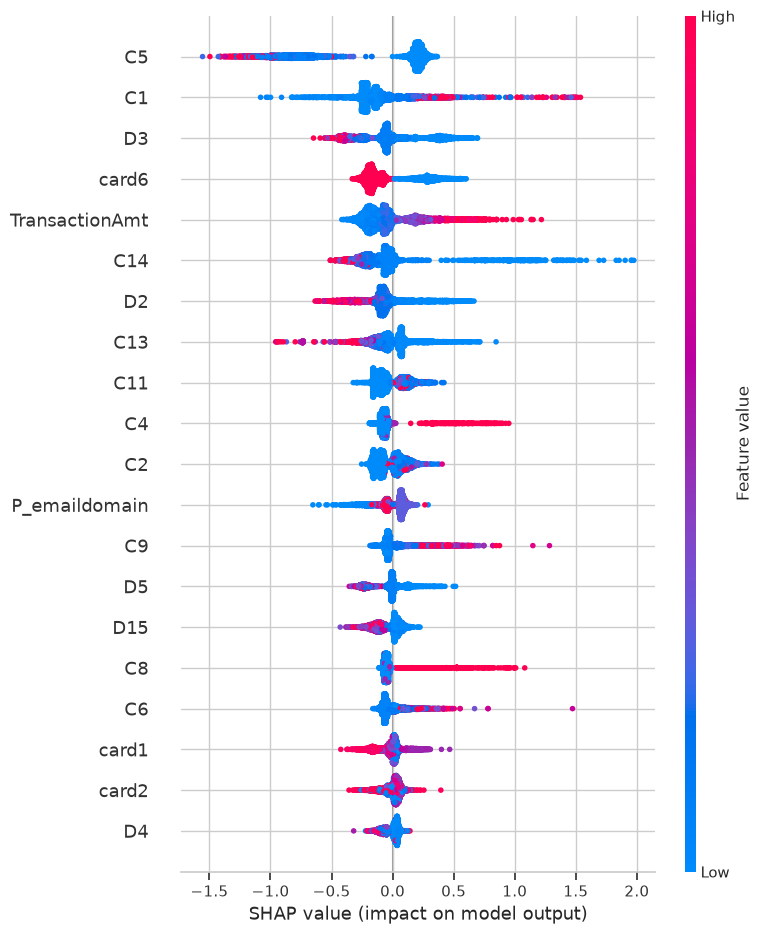

In [9]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap, max_display=20, show=False)
save_plot("03_shap_beeswarm.png")
plt.show()


,feature,mean_abs_shap
0,C5,0.4600
1,C1,0.2079
2,D3,0.2027
3,card6,0.1952
4,TransactionAmt,0.1786
5,C14,0.1763
6,D2,0.1536
7,C13,0.1214
8,C11,0.1049
9,C4,0.0946


Figure sauvegardee : /mnt/c/Users/tanjo/projetcs/fraud-scope/docs/assets/03_shap_top10_features.png


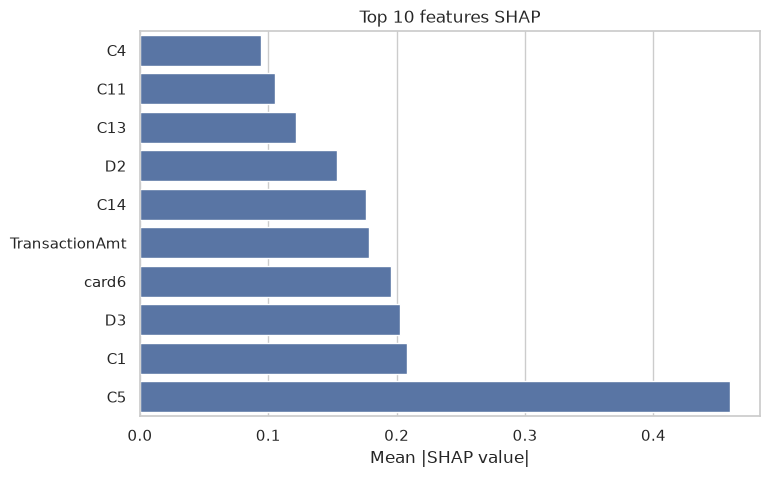

In [10]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = (
    pd.DataFrame({"feature": feature_names_prepared, "mean_abs_shap": mean_abs_shap})
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

top10_shap = shap_importance.head(10)
display(top10_shap)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=top10_shap.sort_values("mean_abs_shap"), x="mean_abs_shap", y="feature", ax=ax)
ax.set_title("Top 10 features SHAP")
ax.set_xlabel("Mean |SHAP value|")
ax.set_ylabel("")
save_plot("03_shap_top10_features.png")
plt.show()


## 6. Cas concrets : fraude detectee et faux positif

On selectionne :

- une fraude correctement detectee au seuil metier ;
- un faux positif, c'est-a-dire une transaction legitime bloquee par le modele.


In [11]:
valid_analysis = valid_pd[["TransactionID", "isFraud", "day_rel"]].copy()
valid_analysis["score_fraude"] = valid_scores
valid_analysis["prediction_threshold"] = valid_pred_threshold

true_positive_candidates = valid_analysis[(valid_analysis["isFraud"] == 1) & (valid_analysis["prediction_threshold"] == 1)]
false_positive_candidates = valid_analysis[(valid_analysis["isFraud"] == 0) & (valid_analysis["prediction_threshold"] == 1)]

if true_positive_candidates.empty:
    raise ValueError("Aucune fraude correctement detectee au seuil choisi. Baisse EXPLANATION_THRESHOLD.")
if false_positive_candidates.empty:
    raise ValueError("Aucun faux positif au seuil choisi. Baisse EXPLANATION_THRESHOLD ou analyse un autre seuil.")

# On prend les cas avec le score le plus eleve pour avoir des explications marquees.
tp_idx = true_positive_candidates.sort_values("score_fraude", ascending=False).index[0]
fp_idx = false_positive_candidates.sort_values("score_fraude", ascending=False).index[0]

cases = {
    "fraude_correctement_detectee": tp_idx,
    "faux_positif": fp_idx,
}

display(valid_analysis.loc[[tp_idx, fp_idx]])


,TransactionID,isFraud,day_rel,score_fraude,prediction_threshold
110377,3569809,1,180,0.9818,1
109704,3569136,0,179,0.9498,1


In [12]:
def make_shap_explanation(row_idx):
    row_prepared = pd.DataFrame(
        X_valid_prepared[row_idx:row_idx + 1],
        columns=feature_names_prepared,
    )
    row_shap = explainer.shap_values(row_prepared)[0]
    row_original = X_valid.iloc[row_idx]
    score = float(valid_scores[row_idx])
    true_label = int(y_valid.iloc[row_idx])
    tx_id = int(valid_pd.iloc[row_idx]["TransactionID"])

    contrib = (
        pd.DataFrame({
            "feature": feature_names_prepared,
            "shap_value": row_shap,
            "abs_shap": np.abs(row_shap),
            "raw_value": [row_original.get(f, np.nan) for f in feature_names_prepared],
        })
        .sort_values("abs_shap", ascending=False)
        .reset_index(drop=True)
    )
    return tx_id, true_label, score, row_prepared, contrib


def format_value(value):
    if pd.isna(value):
        return "manquant"
    if isinstance(value, (float, np.floating)):
        return f"{value:,.2f}"
    return str(value)


def natural_language_explanation(tx_id, true_label, score, contrib, top_n=3):
    positive = contrib[contrib["shap_value"] > 0].head(top_n)
    negative = contrib[contrib["shap_value"] < 0].head(top_n)

    label_text = "frauduleuse" if true_label == 1 else "legitime"
    decision_text = "bloquee / envoyee a analyse" if score >= EXPLANATION_THRESHOLD else "laissee passer"

    parts = []
    for _, row in positive.iterrows():
        parts.append(
            f"{row['feature']}={format_value(row['raw_value'])} augmente le score de fraude"
        )

    mitigating = []
    for _, row in negative.iterrows():
        mitigating.append(
            f"{row['feature']}={format_value(row['raw_value'])} reduit le score"
        )

    explanation = (
        f"Transaction {tx_id} : le modele estime un score de fraude de {score:.1%}. "
        f"La transaction est etiquetee comme {label_text} dans le dataset et serait {decision_text} au seuil {EXPLANATION_THRESHOLD:.2f}. "
    )
    if parts:
        explanation += "Les principaux facteurs de risque sont : " + "; ".join(parts) + ". "
    if mitigating:
        explanation += "Les principaux facteurs qui attenuent le risque sont : " + "; ".join(mitigating) + "."
    return explanation


In [14]:
case_outputs = {}
for case_name, row_idx in cases.items():
    tx_id, true_label, score, row_prepared, contrib = make_shap_explanation(row_idx)
    case_outputs[case_name] = {
        "row_idx": row_idx,
        "tx_id": tx_id,
        "true_label": true_label,
        "score": score,
        "row_prepared": row_prepared,
        "contrib": contrib,
        "text": natural_language_explanation(tx_id, true_label, score, contrib),
    }
    print(f"=== {case_name} ===")
    print(case_outputs[case_name]["text"])
    display(contrib.head(10))


=== fraude_correctement_detectee ===
Transaction 3569809 : le modele estime un score de fraude de 98.2%. La transaction est etiquetee comme frauduleuse dans le dataset et serait bloquee / envoyee a analyse au seuil 0.25. Les principaux facteurs de risque sont : C1=10.00 augmente le score de fraude; C8=4.00 augmente le score de fraude; C4=2.00 augmente le score de fraude. Les principaux facteurs qui attenuent le risque sont : card1=14671 reduit le score; D2=manquant reduit le score; C9=0.00 reduit le score.


,feature,shap_value,abs_shap,raw_value
0,C1,1.1285,1.1285,10.0000
1,C8,0.9999,0.9999,4.0000
2,C4,0.9157,0.9157,2.0000
3,C13,0.7260,0.7260,1.0000
4,TransactionAmt,0.7006,0.7006,400.0000
5,DeviceType,0.4099,0.4099,mobile
6,C7,0.3125,0.3125,0.0000
7,C11,0.2811,0.2811,4.0000
8,C2,0.2808,0.2808,12.0000
9,C5,0.2619,0.2619,0.0000


=== faux_positif ===
Transaction 3569136 : le modele estime un score de fraude de 95.0%. La transaction est etiquetee comme legitime dans le dataset et serait bloquee / envoyee a analyse au seuil 0.25. Les principaux facteurs de risque sont : C1=12.00 augmente le score de fraude; C4=4.00 augmente le score de fraude; C7=4.00 augmente le score de fraude. Les principaux facteurs qui attenuent le risque sont : TransactionAmt=31.85 reduit le score; C9=0.00 reduit le score; card2=545.00 reduit le score.


,feature,shap_value,abs_shap,raw_value
0,C1,0.9761,0.9761,12.0000
1,C4,0.8199,0.8199,4.0000
2,C7,0.7778,0.7778,4.0000
3,C8,0.7349,0.7349,7.0000
4,C13,0.5912,0.5912,1.0000
5,C11,0.3275,0.3275,7.0000
6,card6,0.2669,0.2669,credit
7,C5,0.2603,0.2603,0.0000
8,C14,0.1823,0.1823,1.0000
9,D5,0.1775,0.1775,0.0000


## 7. Waterfall plots SHAP

Les waterfall plots montrent comment chaque feature fait monter ou descendre le score par rapport a la valeur moyenne du modele.


Figure sauvegardee : /mnt/c/Users/tanjo/projetcs/fraud-scope/docs/assets/03_shap_waterfall_fraude_correctement_detectee.png


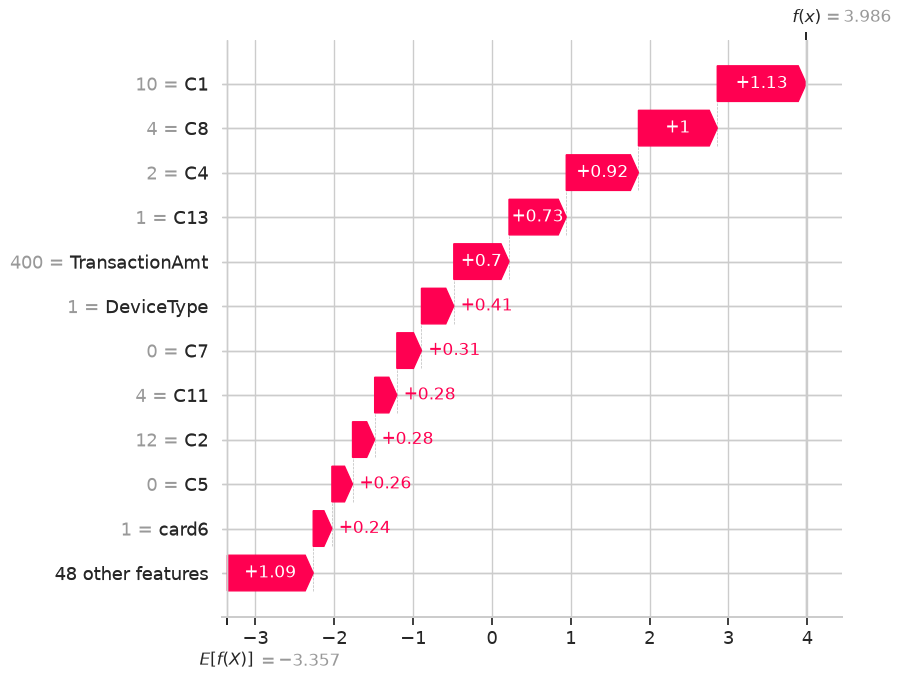

Figure sauvegardee : /mnt/c/Users/tanjo/projetcs/fraud-scope/docs/assets/03_shap_waterfall_faux_positif.png


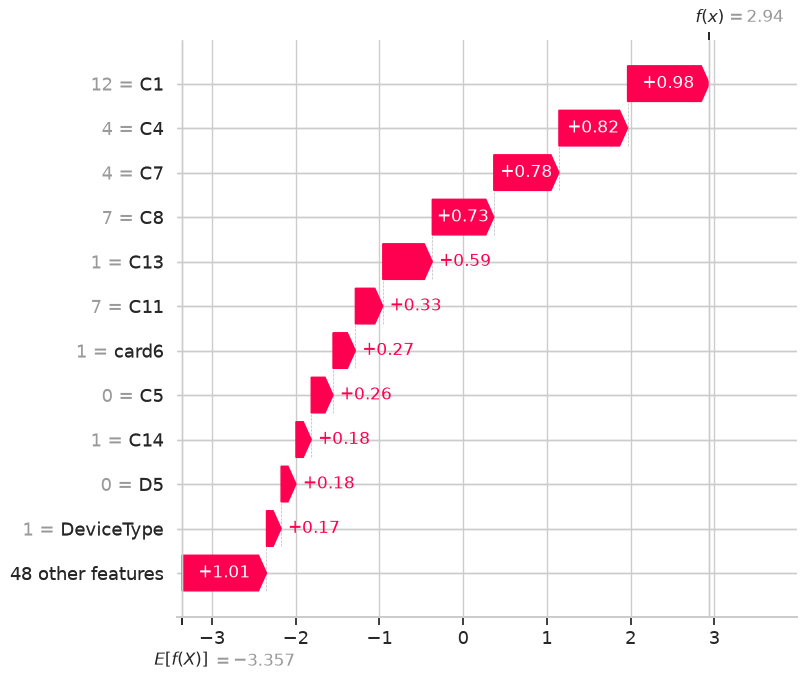

In [15]:
for case_name, case in case_outputs.items():
    row_prepared = case["row_prepared"]
    row_shap = explainer.shap_values(row_prepared)[0]
    base_value = explainer.expected_value
    if isinstance(base_value, (list, np.ndarray)):
        base_value = np.asarray(base_value).ravel()[0]

    explanation = shap.Explanation(
        values=row_shap,
        base_values=base_value,
        data=row_prepared.iloc[0].values,
        feature_names=feature_names_prepared,
    )

    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(explanation, max_display=12, show=False)
    save_plot(f"03_shap_waterfall_{case_name}.png")
    plt.show()


## 8. Template d'explication metier

Template utilisable dans une interface analyste :

> Cette transaction a ete bloquee car le modele lui attribue un score de fraude de `{score}`. Les principaux facteurs qui augmentent le risque sont `{feature_1}`, `{feature_2}` et `{feature_3}`. Les facteurs qui attenuent le risque sont `{mitigating_feature_1}` et `{mitigating_feature_2}`. Cette explication est basee sur les contributions SHAP locales de la transaction.

La cellule suivante produit un tableau recapitulatif pret a reprendre dans le rapport.


In [16]:
explanation_rows = []
for case_name, case in case_outputs.items():
    positive = case["contrib"][case["contrib"]["shap_value"] > 0].head(3)
    negative = case["contrib"][case["contrib"]["shap_value"] < 0].head(3)
    explanation_rows.append({
        "cas": case_name,
        "TransactionID": case["tx_id"],
        "label_reel": "fraude" if case["true_label"] == 1 else "legitime",
        "score_fraude": case["score"],
        "top_facteurs_risque": "; ".join(positive["feature"].tolist()),
        "top_facteurs_attenuants": "; ".join(negative["feature"].tolist()),
        "explication_metier": case["text"],
    })

explanations_df = pd.DataFrame(explanation_rows)
display(explanations_df)

output_path = PROJECT_ROOT / "docs" / "shap_explanations_summary.csv"
explanations_df.to_csv(output_path, index=False)
print(f"Resume sauvegarde : {output_path}")


,cas,TransactionID,label_reel,score_fraude,top_facteurs_risque,top_facteurs_attenuants,explication_metier
0,fraude_correctement_detectee,3569809,fraude,0.9818,C1; C8; C4,card1; D2; C9,Transaction 3569809 : le modele estime un scor...
1,faux_positif,3569136,legitime,0.9498,C1; C4; C7,TransactionAmt; C9; card2,Transaction 3569136 : le modele estime un scor...


Resume sauvegarde : /mnt/c/Users/tanjo/projetcs/fraud-scope/docs/shap_explanations_summary.csv


## 9. Conclusion

A completer apres execution :

- Les features SHAP les plus importantes sont a reporter dans le rapport.
- La fraude correctement detectee doit etre expliquee en langage analyste.
- Le faux positif doit etre analyse pour comprendre pourquoi le modele bloque une transaction legitime.
- Les plots sauvegardes sont dans `docs/assets/` :
  - `03_shap_beeswarm.png`
  - `03_shap_top10_features.png`
  - `03_shap_waterfall_fraude_correctement_detectee.png`
  - `03_shap_waterfall_faux_positif.png`
